# 03 — Pandas Deep Dive on Real FastF1 Data (ARIS Wk 2 Day 1)

**Goal:** move pandas from "I followed a tutorial" to *"I can answer a multi-driver pace question from a blank cell without docs."*

Companion to James Powell's *Pandas From The Ground Up* (minutes 0:00 – 1:15:00 today). Watch the video at 1.5× and translate every demo example into the equivalent on Bahrain 2024 `laps` here. No synthetic data — every cell touches the real frame.

**Blocks covered:**
- Block 1 — imports, Bahrain 2024 load, James Powell translations
- Block 2 — Q1 (per-driver median race lap), Q2 (compound pace deltas), Q3 (VER pace progression chart)
- Block 3 — merge drills (`merge_asof` lap→weather, standard merge lap→results, TrackTemp vs pace)

Run top-to-bottom on a fresh kernel. Clear outputs before committing.

## Block 1 — Imports + Bahrain 2024 load + James Powell warmup

Cache was pre-warmed in Wk 1 (`scripts/prewarm_cache.py`) — Bahrain 2024 R is already on disk, no network call.

In [2]:
from pathlib import Path

import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CACHE = Path("..") / "fastf1_cache"
CACHE.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))

print("pandas", pd.__version__, "| numpy", np.__version__, "| fastf1", fastf1.__version__)

pandas 2.3.3 | numpy 2.4.4 | fastf1 3.8.3


In [3]:
session = fastf1.get_session(2024, "Bahrain", "R")
session.load(laps=True, telemetry=False, weather=True, messages=False)

laps = session.laps.copy()
print("laps shape:", laps.shape)
print("columns:", list(laps.columns))
laps.head(3)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


laps shape: (1129, 31)
columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:01:37.489000,VER,1,0 days 00:01:37.284000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:41.266000,...,False,Red Bull Racing,0 days 00:59:59.911000,NaT,12,1.0,None,,False,False
1,0 days 01:03:13.785000,VER,1,0 days 00:01:36.296000,2.0,1.0,NaT,NaT,0 days 00:00:30.916000,0 days 00:00:41.661000,...,False,Red Bull Racing,0 days 01:01:37.489000,NaT,1,1.0,None,,False,True
2,0 days 01:04:50.538000,VER,1,0 days 00:01:36.753000,3.0,1.0,NaT,NaT,0 days 00:00:30.999000,0 days 00:00:41.966000,...,False,Red Bull Racing,0 days 01:03:13.785000,NaT,1,1.0,None,,False,True


### James Powell translations

Each cell below = one Powell demo idiom, translated to `laps`. Add a one-line `# what this proved` comment after each so future-you re-reads the notebook and learns. Append cells freely as you watch — these three are the starter set.

In [4]:
# Powell idiom: df.dtypes — know your column types before any analysis
# Translation: which FastF1 columns are timedelta vs float vs object?
laps.dtypes
# what this proved: LapTime / Sector*Time / PitInTime / PitOutTime are timedelta64[ns],
# Compound / Driver / TrackStatus are object (strings), TyreLife / LapNumber are float64.

Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedelta64[ns]
Sector3SessionTime    timedelta64[ns]
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
IsPersonalBest                   bool
Compound                       object
TyreLife                      float64
FreshTyre                        bool
Team                           object
LapStartTime          timedelta64[ns]
LapStartDate           datetime64[ns]
TrackStatus                    object
Position    

In [5]:
# Powell idiom: df.groupby(K).agg(...) — the workhorse
# Translation: laps per driver as a smoke test before any real analysis
laps.groupby("Driver").agg(n_laps=("LapNumber", "count")).sort_values("n_laps", ascending=False).head()
# what this proved: groupby returns one row per group; .agg with named tuples is the
# readable form (vs .agg({'col': 'fn'}) which is shorter but harder to extend).

,n_laps
Driver,
ALO,57
PER,57
LEC,57
HAM,57
STR,57


In [6]:
# Powell idiom: .dt accessor on datetime/timedelta columns
# Translation: convert LapTime (timedelta) to seconds for downstream math
laps["LapTimeS"] = laps["LapTime"].dt.total_seconds()
laps[["Driver", "LapNumber", "LapTime", "LapTimeS"]].head()
# what this proved: timedelta -> float seconds via .dt.total_seconds().
# Doing this once up-front is cleaner than re-converting in every cell.

,Driver,LapNumber,LapTime,LapTimeS
0,VER,1.0,0 days 00:01:37.284000,97.284
1,VER,2.0,0 days 00:01:36.296000,96.296
2,VER,3.0,0 days 00:01:36.753000,96.753
3,VER,4.0,0 days 00:01:36.647000,96.647
4,VER,5.0,0 days 00:01:37.173000,97.173


## Block 2 — Three real questions on real data

Each Q = markdown framing, code, one-line answer.

### Q1 — Each driver's median race lap time, ignoring in/out laps and laps under safety car

**Filters:** drop pit in (`PitInTime` notna), drop pit out (`PitOutTime` notna), keep only green or yellow-not-SC track status (`TrackStatus` in `{'1', '2'}`).

**Expected:** VER, PER, LEC, SAI near the top of the table.

In [7]:
clean = laps[
    laps["PitInTime"].isna()
    & laps["PitOutTime"].isna()
    & laps["TrackStatus"].isin(["1", "2"])
].copy()

q1 = (
    clean.groupby("Driver")
    .agg(median_s=("LapTimeS", "median"), n_laps=("LapTimeS", "count"))
    .sort_values("median_s")
)
q1

,median_s,n_laps
Driver,,
VER,95.4095,50
SAI,96.1040,51
PER,96.2110,51
RUS,96.4400,51
NOR,96.5650,51
HAM,96.6330,51
PIA,96.6440,51
LEC,96.7560,51
HUL,96.7895,48


**Answer:** _(fill after running)_ — top of table should be VER / PER / LEC / SAI cluster within ~0.3 s.

### Q2 — Average pace delta between compounds, per driver, on green laps only

**Approach:** pivot `Driver × Compound` of median `LapTimeS`, then subtract columns. Negative `SOFT_vs_HARD` means softs faster (expected).

In [8]:
green = laps[laps["TrackStatus"] == "1"].copy()

pivot = (
    green.groupby(["Driver", "Compound"])["LapTimeS"]
    .median()
    .unstack("Compound")
)

# Bahrain 2024 ran SOFT + MEDIUM + HARD; some drivers may not have used all three.
for fast, slow in [("SOFT", "MEDIUM"), ("SOFT", "HARD"), ("MEDIUM", "HARD")]:
    if fast in pivot.columns and slow in pivot.columns:
        pivot[f"{fast}_vs_{slow}"] = pivot[fast] - pivot[slow]

pivot

Compound,HARD,SOFT,SOFT_vs_HARD
Driver,,,
ALB,97.6160,98.8230,1.2070
ALO,97.0510,98.5540,1.5030
BOT,97.3930,99.0775,1.6845
GAS,97.8680,96.0860,-1.7820
HAM,96.1650,98.2800,2.1150
HUL,97.4125,95.5900,-1.8225
LEC,96.5525,98.0620,1.5095
MAG,97.5830,98.8610,1.2780
NOR,96.3195,98.0100,1.6905


**Sanity check:** all `SOFT_vs_HARD` deltas should be negative for drivers who actually pushed on softs. A positive number = small sample size or a stint that never came in (verify with `green.groupby(['Driver', 'Compound']).size()`).

### Q3 — VER lap-time progression with median pace line + pit-stop markers

**Approach:** one matplotlib line per stint, color-coded by compound. Horizontal line = VER's median green-lap pace from Q1. Vertical dashed lines at lap numbers where `PitInTime` is not null. Saved to `docs/screenshots/wk2-ver-pace-progression.png` as a README candidate for Sat.

saved: ..\docs\screenshots\wk2-ver-pace-progression.png


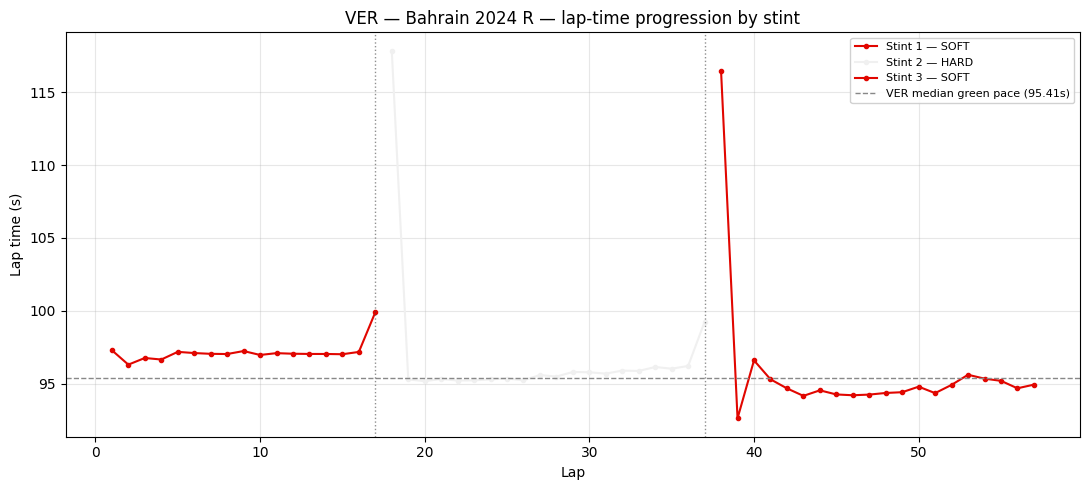

In [9]:
ver = laps[laps["Driver"] == "VER"].sort_values("LapNumber").copy()
ver_median_green = q1.loc["VER", "median_s"]

compound_colors = {
    "SOFT": "#e10600",
    "MEDIUM": "#ffcc00",
    "HARD": "#f0f0f0",
    "INTERMEDIATE": "#43b02a",
    "WET": "#0067ad",
}

fig, ax = plt.subplots(figsize=(11, 5))

# one line segment per stint
for stint_num, stint in ver.groupby("Stint"):
    compound = stint["Compound"].iloc[0]
    ax.plot(
        stint["LapNumber"],
        stint["LapTimeS"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=compound_colors.get(compound, "#888888"),
        label=f"Stint {int(stint_num)} — {compound}",
    )

# median green pace reference
ax.axhline(
    ver_median_green,
    linestyle="--",
    linewidth=1,
    color="#888888",
    label=f"VER median green pace ({ver_median_green:.2f}s)",
)

# pit-stop markers
pit_laps = ver.loc[ver["PitInTime"].notna(), "LapNumber"]
for lap_num in pit_laps:
    ax.axvline(lap_num, linestyle=":", linewidth=1, color="#444444", alpha=0.6)

ax.set_xlabel("Lap")
ax.set_ylabel("Lap time (s)")
ax.set_title("VER — Bahrain 2024 R — lap-time progression by stint")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
fig.tight_layout()

out = Path("..") / "docs" / "screenshots" / "wk2-ver-pace-progression.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=140, bbox_inches="tight")
print("saved:", out)
plt.show()

## Block 3 — Merge mechanics on FastF1 data

Three frames per session: `laps`, `session.weather_data`, `session.results`. Real strategy work joins them.

In [10]:
weather = session.weather_data.copy()
results = session.results.copy()
print("weather:", weather.shape, "| cols:", list(weather.columns))
print("results:", results.shape, "| cols:", list(results.columns)[:8], "...")
weather.head(3)

weather: (157, 8) | cols: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
results: (20, 22) | cols: ['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName', 'TeamColor', 'TeamId', 'FirstName'] ...


,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:14.093000,18.9,46.0,1017.1,False,26.5,162,0.9
1,0 days 00:01:14.084000,18.9,46.0,1017.0,False,26.5,55,1.0
2,0 days 00:02:14.093000,18.9,46.0,1017.0,False,26.5,55,1.0


### Drill 1 — `merge_asof`: lap → weather

Weather is timestamped at ~1 min cadence; laps have `LapStartTime` (a timedelta from session start). `merge_asof` joins each lap to the *latest weather sample at or before* the lap start. Both sides must be sorted on the join key.

In [11]:
laps_sorted = laps.sort_values("LapStartTime").reset_index(drop=True)
weather_sorted = weather.sort_values("Time").reset_index(drop=True)

laps_wx = pd.merge_asof(
    laps_sorted,
    weather_sorted,
    left_on="LapStartTime",
    right_on="Time",
    direction="backward",
)

print("shape preserved?", laps_wx.shape[0] == len(laps), "|", laps_wx.shape)
laps_wx[["Driver", "LapNumber", "LapTimeS", "AirTemp", "TrackTemp", "Rainfall"]].head()

shape preserved? True | (1129, 40)


,Driver,LapNumber,LapTimeS,AirTemp,TrackTemp,Rainfall
0,VER,1.0,97.284,18.3,23.8,False
1,LEC,1.0,98.271,18.3,23.8,False
2,RUS,1.0,99.228,18.3,23.8,False
3,NOR,1.0,102.168,18.3,23.8,False
4,HAM,1.0,103.122,18.3,23.8,False


### Drill 2 — Standard merge: lap → results

`results` has finishing position and team per driver. Standard left-merge on `Driver` ⇔ `Abbreviation`.

In [12]:
laps_full = laps_wx.merge(
    results[["Abbreviation", "TeamName", "Position"]],
    left_on="Driver",
    right_on="Abbreviation",
    how="left",
)

print("shape after results join:", laps_full.shape)
laps_full[["Driver", "TeamName", "Position", "LapNumber", "LapTimeS", "TrackTemp"]].head()

shape after results join: (1129, 43)


KeyError: "['Position'] not in index"

### Drill 3 — Did track temp predict pace? (VER only, green laps only)

Scatter `TrackTemp` vs `LapTimeS`, compute Pearson correlation. Eyeball the slope before reading the number.

In [ ]:
ver_green = laps_full[
    (laps_full["Driver"] == "VER")
    & (laps_full["TrackStatus"] == "1")
    & laps_full["PitInTime"].isna()
    & laps_full["PitOutTime"].isna()
].copy()

r = ver_green[["TrackTemp", "LapTimeS"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ver_green["TrackTemp"], ver_green["LapTimeS"], s=18, alpha=0.7, color="#e10600")
ax.set_xlabel("Track temperature (°C)")
ax.set_ylabel("Lap time (s)")
ax.set_title(f"VER green laps — TrackTemp vs LapTime (Pearson r = {r:.3f})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Pearson r(TrackTemp, LapTimeS) for VER green laps: {r:.4f}")
print("interpretation: positive r = hotter track → slower lap (tyre degradation hypothesis).")

## End-of-day reflection

Per Block 5: did I answer Q1–Q3 from a blank cell, or did I lean on docs?

If lean-on-docs > 30%, Tue morning's first 30 min is a repeat drill, not stint work. Log the three fragile idioms in `learning/notes/pandas-gaps.md`.

**Idioms I leaned on docs for (fill in):**
1. _
2. _
3. _